# Análise Exploratória de Dados — Board Game Geek (BGG)

## 1. Importações e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

import warnings
warnings.filterwarnings('ignore')

# Estilo global dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [2]:
DATA_PATH = '../data/bgg_dataset.csv'

df_raw = pd.read_csv(DATA_PATH, on_bad_lines='skip')
print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (24785, 19)


,rank,title,year,description,geek_rating,avg_rating,num_voters,price,num_players,play_time,suggested_age,complexity,designers,artists,publishers,developer,categories,mechanisms,relationship
0,1,Brass: Birmingham,2018.0,"Build networks, grow industries, and navigate ...",8.394,8.56,58832,$79.99,2–4–,60–120–,14+,3.86 / 5,Gavan Brown / Matt Tolman / Martin Wallace,Gavan Brown / Lina Cossette / David Forest / G...,Roxley / Arclight Games / Board Game Rookie / ...,NaN,Age of Reason / Economic / Industry / Manufact...,Chaining / End Game Bonuses / Hand Management ...,Reimplements: Brass: Lancashire | Reimplemente...
1,2,Ark Nova,2021.0,"Plan and build a modern, scientifically manage...",8.354,8.54,61446,$74.95,1–4–,90–150–,14+,3.80 / 5,Mathias Wigge,Steffen Bieker / Loïc Billiau / Dennis Lohausen,Feuerland Spiele / Capstone Games / CMON Globa...,NaN,Animals / Card Game / Environmental,Contracts / End Game Bonuses / Events / Grid C...,Reimplemented by: + 0more
2,3,Pandemic Legacy: Season 1,2015.0,Mutating diseases are spreading around the wor...,8.345,8.50,57473,NaN,2–4–,60,13+,2.83 / 5,Rob Daviau / Matt Leacock,Chris Quilliams,Z-Man Games / Asterion Press / Devir / Filosof...,NaN,Environmental / Medical,Action Points / Cooperative Game / Hand Manage...,Reimplements: Pandemic | Reimplemented by: + 0...


## 2. Visão Geral do Dataset

In [ ]:
df_raw.info()

=== INFORMAÇÕES GERAIS ===
Linhas: 24,785
Colunas: 19

<class 'pandas.DataFrame'>
RangeIndex: 24785 entries, 0 to 24784
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rank           24785 non-null  int64  
 1   title          24785 non-null  str    
 2   year           24600 non-null  float64
 3   description    18476 non-null  str    
 4   geek_rating    24785 non-null  float64
 5   avg_rating     24785 non-null  float64
 6   num_voters     24785 non-null  int64  
 7   price          640 non-null    str    
 8   num_players    24760 non-null  str    
 9   play_time      23912 non-null  str    
 10  suggested_age  23436 non-null  str    
 11  complexity     24785 non-null  str    
 12  designers      8907 non-null   str    
 13  artists        6924 non-null   str    
 14  publishers     9029 non-null   str    
 15  developer      514 non-null    str    
 16  categories     8960 non-null   str    
 17  mechan

In [ ]:
df_raw[['rank', 'geek_rating', 'avg_rating', 'num_voters']].describe().round(3)

=== ESTATÍSTICAS DESCRITIVAS — COLUNAS NUMÉRICAS ===


,rank,geek_rating,avg_rating,num_voters
count,24785.000,24785.000,24785.000,24785.000
mean,15457.052,5.692,6.460,1104.373
std,9433.042,0.371,0.932,4687.409
min,1.000,5.268,1.180,30.000
25%,6408.000,5.507,5.850,53.000
50%,17111.000,5.528,6.500,129.000
75%,23962.000,5.695,7.090,511.000
max,30700.000,8.394,9.840,142657.000


## 3. Análise de Valores Ausentes

In [6]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

df_missing = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})
df_missing = df_missing[df_missing['Ausentes'] > 0]
print(df_missing.to_string())

               Ausentes  Percentual (%)
developer         24271           97.93
price             24145           97.42
relationship      18846           76.04
artists           17861           72.06
mechanisms        16415           66.23
designers         15878           64.06
categories        15825           63.85
publishers        15756           63.57
description        6309           25.45
suggested_age      1349            5.44
play_time           873            3.52
year                185            0.75
num_players          25            0.10


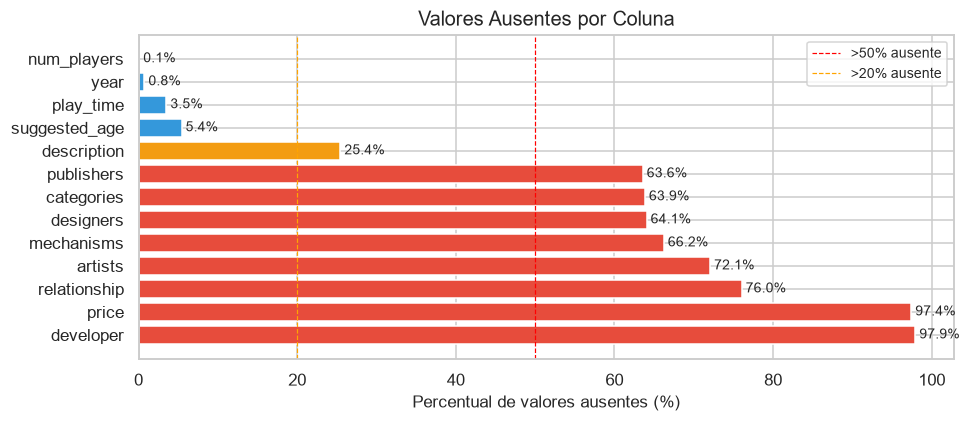

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#3498db'
          for p in df_missing['Percentual (%)']]

bars = ax.barh(df_missing.index, df_missing['Percentual (%)'], color=colors)
ax.set_xlabel('Percentual de valores ausentes (%)')
ax.set_title('Valores Ausentes por Coluna')
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, label='>50% ausente')
ax.axvline(20, color='orange', linestyle='--', linewidth=0.8, label='>20% ausente')

for bar, val in zip(bars, df_missing['Percentual (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Observações:**
- `developer` (~97%) e `price` (~97%) têm pouquíssima cobertura → provavelmente inviáveis para modelagem direta.
- `artists`, `publishers`, `designers`, `relationship`, `categories`, `mechanisms` têm ~64–72% de ausência → requerem tratamento cuidadoso.
- `description` ausente em ~25% das linhas → será tratado como token especial no pipeline de NLP.

## 4. Tratamento e Parsing das Colunas

In [ ]:
df = df_raw.copy()

df['complexity'] = (
    df['complexity']
    .astype(str)
    .str.extract(r'([\d\.]+)\s*/\s*5')[0]
    .astype(float)
)

df['price'] = (
    df['price']
    .astype(str)
    .str.replace('[^\d\.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

player_parsed = (
    df['num_players']
    .astype(str)
    .str.extractall(r'(\d+)')
    .unstack(level='match')
    .iloc[:, :2]
)
player_parsed.columns = ['min_players', 'max_players']
df = df.join(player_parsed.astype(float))

time_parsed = (
    df['play_time']
    .astype(str)
    .str.extractall(r'(\d+)')
    .unstack(level='match')
    .iloc[:, :2]
)
time_parsed.columns = ['min_time', 'max_time']
df = df.join(time_parsed.astype(float))
df['avg_time'] = df[['min_time', 'max_time']].mean(axis=1)

df['suggested_age_num'] = (
    df['suggested_age']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

df['year'] = df['year'].where(df['year'].between(1000, 2027))

def parse_list_col(series: pd.Series) -> pd.Series:
    return series.apply(
        lambda x: [item.strip() for item in str(x).split('/') if item.strip()]
        if pd.notna(x) else np.nan
    )

df['categories'] = parse_list_col(df['categories'])
df['mechanisms'] = parse_list_col(df['mechanisms'])

print('Colunas derivadas criadas com sucesso.')
df[['complexity', 'price', 'min_players', 'max_players',
    'min_time', 'max_time', 'avg_time', 'suggested_age_num']].describe().round(2)

Colunas derivadas criadas com sucesso.


,complexity,price,min_players,max_players,min_time,max_time,avg_time,suggested_age_num
count,24785.00,640.00,24760.00,20451.00,23912.00,10342.00,23912.00,23436.00
mean,1.91,49.30,1.95,6.88,56.58,127.12,74.54,10.26
std,0.83,43.17,0.71,13.82,415.55,929.33,516.86,2.90
min,0.00,5.71,0.00,0.00,1.00,1.00,1.00,1.00
25%,1.25,24.99,2.00,4.00,20.00,30.00,22.50,8.00
50%,1.83,39.95,2.00,5.00,30.00,60.00,37.50,10.00
75%,2.43,59.99,2.00,6.00,60.00,100.00,67.50,12.00
max,4.82,449.99,10.00,999.00,60000.00,84000.00,60000.00,26.00


## 5. Análise Univariada — Variáveis Numéricas

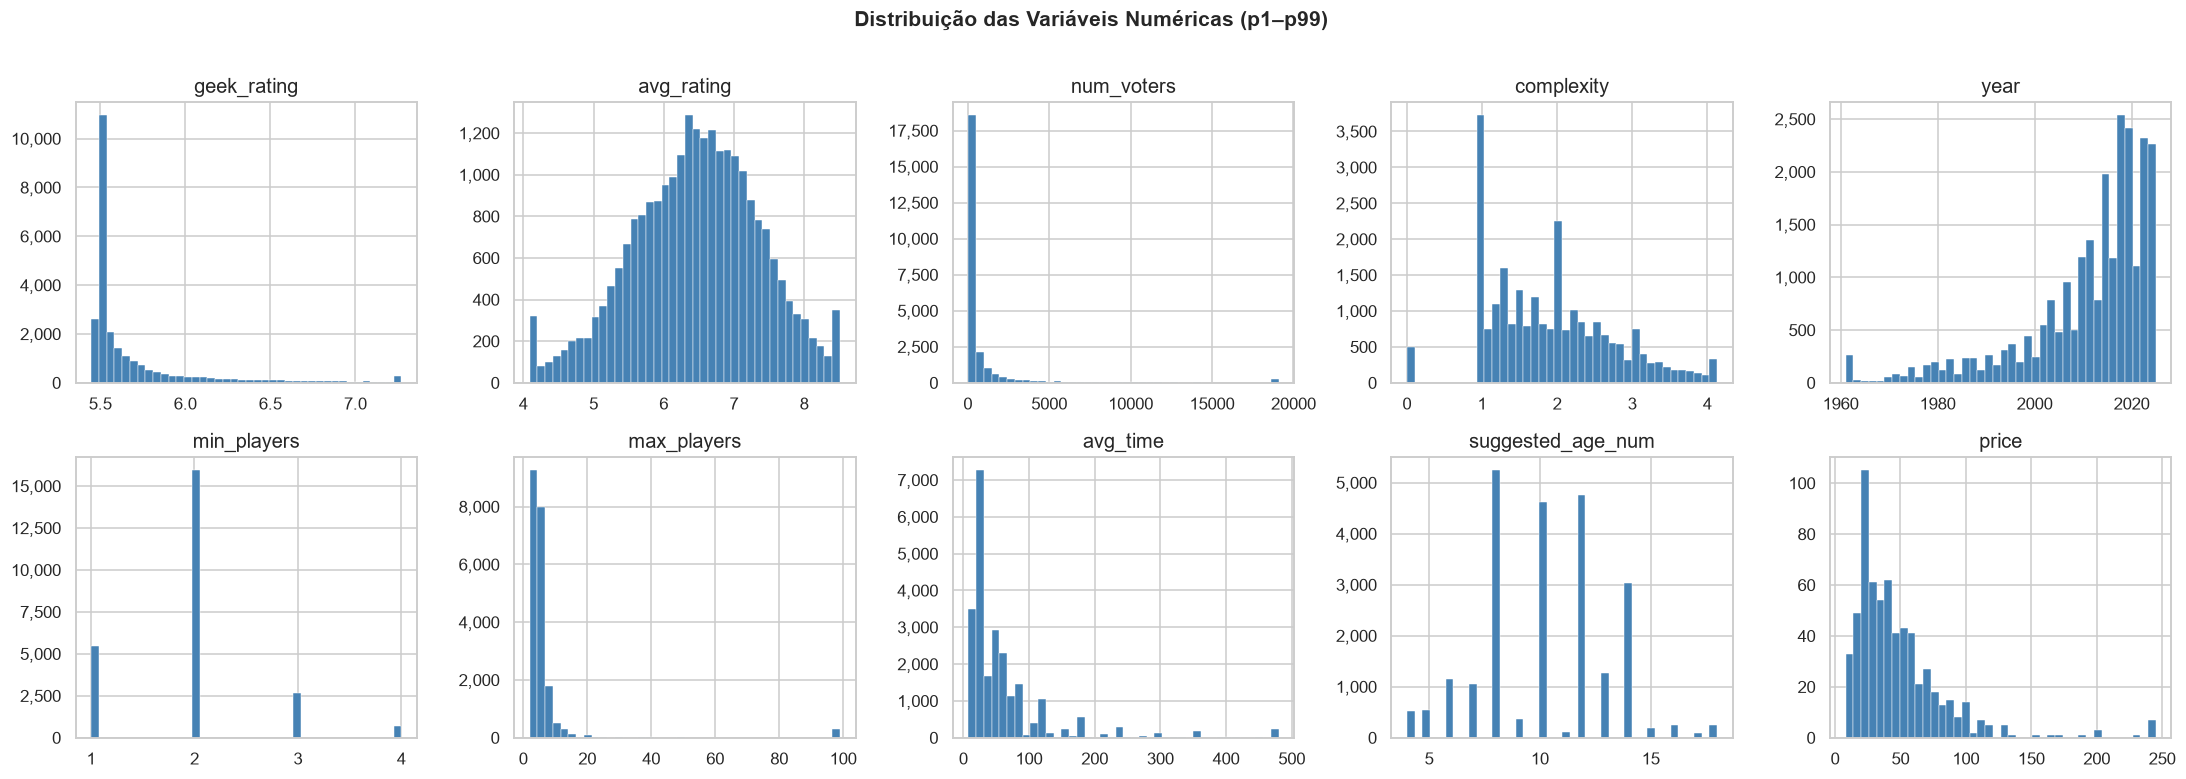

In [ ]:
num_cols = ['geek_rating', 'avg_rating', 'num_voters', 'complexity', 'year',
            'min_players', 'max_players', 'avg_time', 'suggested_age_num', 'price']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    q01, q99 = data.quantile(0.01), data.quantile(0.99)
    data_plot = data.clip(q01, q99)
    ax.hist(data_plot, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribuição das Variáveis Numéricas (p1–p99)', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

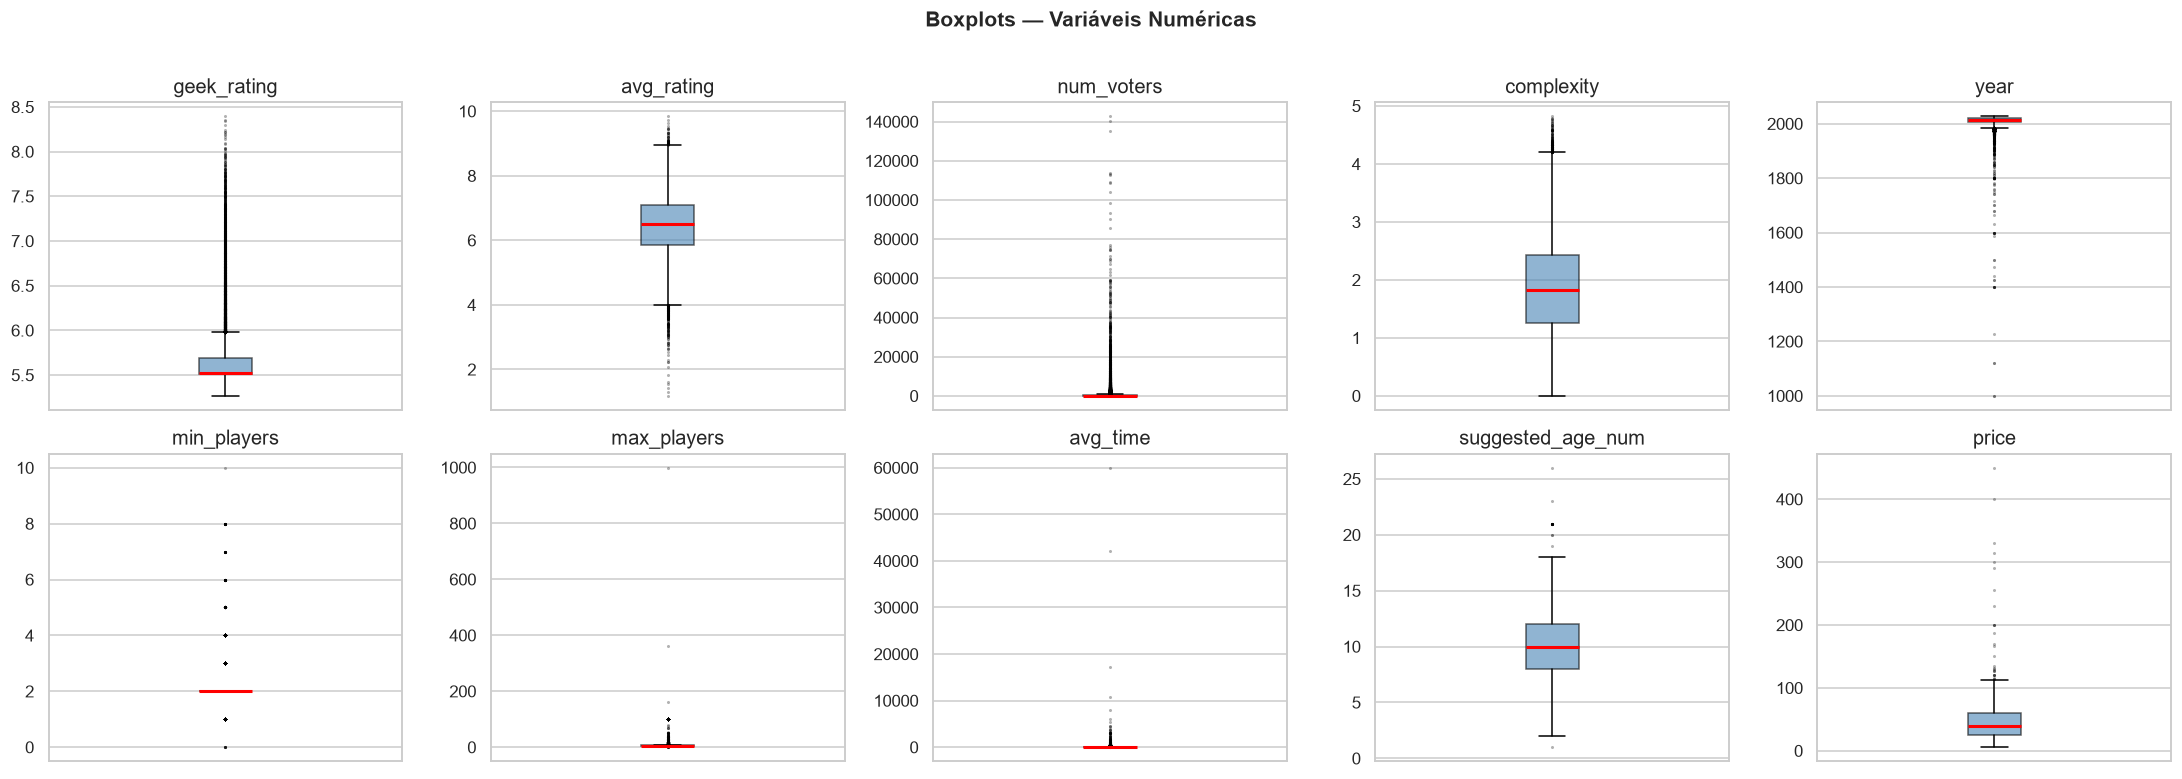

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Boxplots — Variáveis Numéricas', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

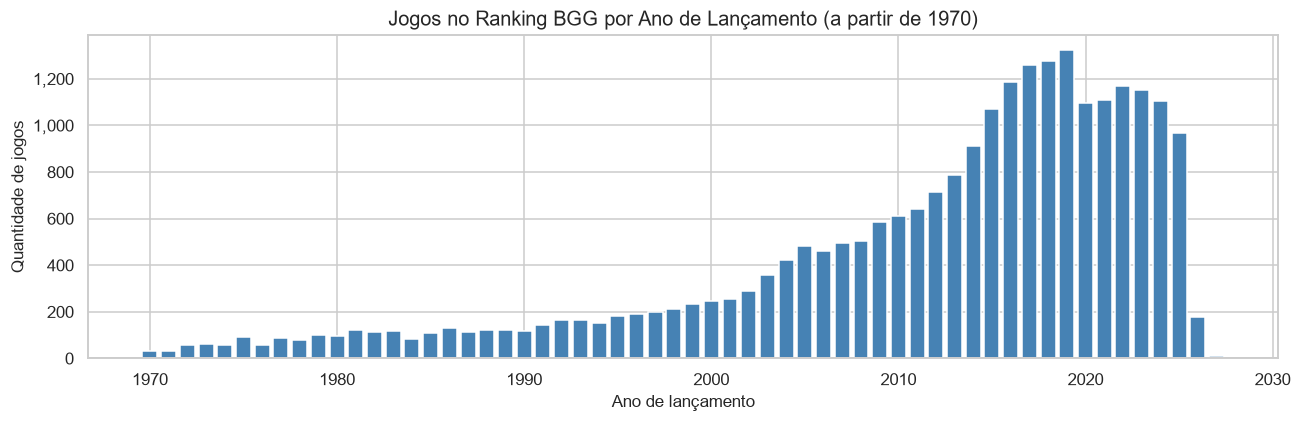

In [ ]:
year_counts = (
    df[df['year'] >= 1970]['year']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue', width=0.8)
ax.set_xlabel('Ano de lançamento')
ax.set_ylabel('Quantidade de jogos')
ax.set_title('Jogos no Ranking BGG por Ano de Lançamento (a partir de 1970)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

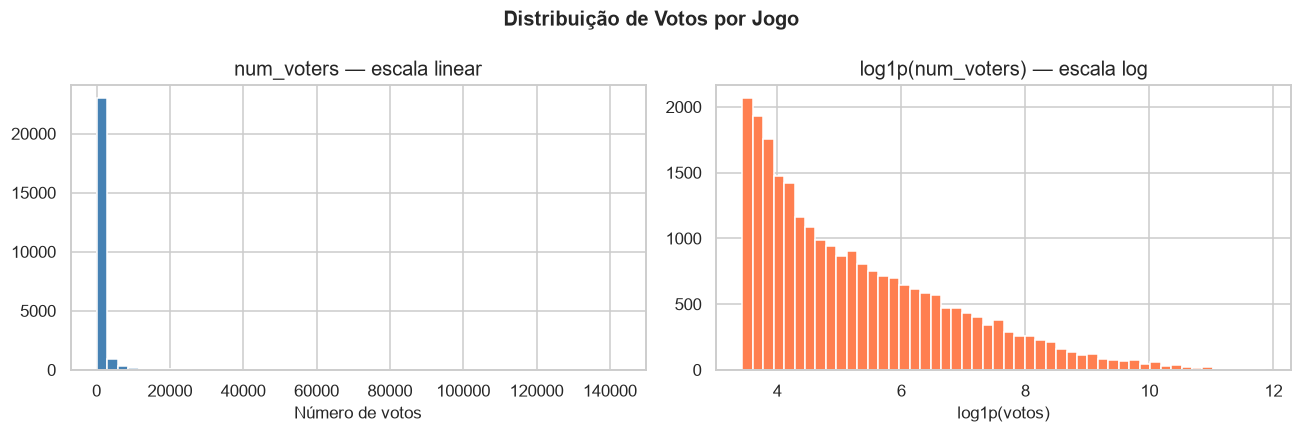

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['num_voters'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('num_voters — escala linear')
axes[0].set_xlabel('Número de votos')

axes[1].hist(np.log1p(df['num_voters'].dropna()), bins=50, color='coral', edgecolor='white')
axes[1].set_title('log1p(num_voters) — escala log')
axes[1].set_xlabel('log1p(votos)')

plt.suptitle('Distribuição de Votos por Jogo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

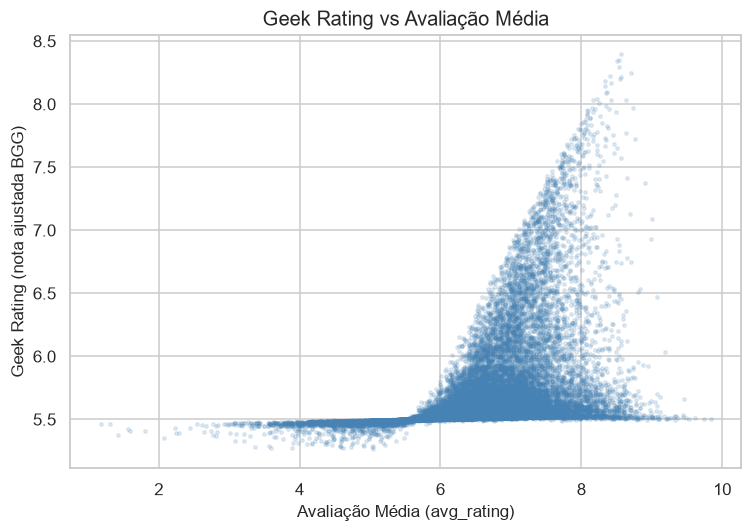

Correlações:
             avg_rating  geek_rating  num_voters
avg_rating        1.000        0.470       0.187
geek_rating       0.470        1.000       0.651
num_voters        0.187        0.651       1.000


In [ ]:
# --- Geek Rating vs Avg Rating ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['avg_rating'], df['geek_rating'],
           alpha=0.15, s=5, color='steelblue')
ax.set_xlabel('Avaliação Média (avg_rating)')
ax.set_ylabel('Geek Rating (nota ajustada BGG)')
ax.set_title('Geek Rating vs Avaliação Média')
plt.tight_layout()
plt.show()

corr = df[['avg_rating', 'geek_rating', 'num_voters']].corr()
print('Correlações:')
print(corr.round(3))

## 6. Análise Univariada — Variáveis Categóricas (Listas)

In [ ]:
def analyze_distribution(df: pd.DataFrame, col_name: str):
    """Analisa a distribuição de colunas que contêm listas (explode)."""
    exploded = df[col_name].explode().dropna()

    counts = exploded.value_counts()
    perc = counts / len(exploded) * 100
    cum_perc = perc.cumsum()

    resumo = pd.DataFrame({
        'Frequencia': counts,
        'Porcentagem (%)': perc.round(2),
        'Acumulada (%)': cum_perc.round(2)
    })

    print(f"\n--- Distribuição da coluna: {col_name.upper()} ---")
    print(f"Total de itens únicos: {len(counts)}")
    print("\nTop 10 mais frequentes:")
    print(resumo.head(10))
    print("\nÚltimos 5 (menos frequentes):")
    print(resumo.tail(5))

    return resumo

In [15]:
resumo_cat = analyze_distribution(df, 'categories')
resumo_mec = analyze_distribution(df, 'mechanisms')


--- Distribuição da coluna: CATEGORIES ---
Total de itens únicos: 92

Top 10 mais frequentes:
                   Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                   
Card Game                2790            10.65          10.65
Wargame                  1314             5.02          15.67
Fantasy                  1269             4.84          20.51
Fighting                  831             3.17          23.68
Economic                  805             3.07          26.76
Dice                      796             3.04          29.79
Science Fiction           782             2.99          32.78
Party Game                762             2.91          35.69
Animals                   608             2.32          38.01
Abstract Strategy         585             2.23          40.24

Últimos 5 (menos frequentes):
                         Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                    

In [ ]:
print('=== CATEGORIAS ===')
print(resumo_cat.head(40))  # 43.48% das categorias representam 81.16% dos jogos

print('\n=== MECÂNICAS ===')
print(resumo_mec.head(55))  # 25.11% das mecânicas representam 81.99% dos jogos

=== CATEGORIAS ===
                        Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                        
Card Game                     2790            10.65          10.65
Wargame                       1314             5.02          15.67
Fantasy                       1269             4.84          20.51
Fighting                       831             3.17          23.68
Economic                       805             3.07          26.76
Dice                           796             3.04          29.79
Science Fiction                782             2.99          32.78
Party Game                     762             2.91          35.69
Animals                        608             2.32          38.01
Abstract Strategy              585             2.23          40.24
Children's Game                565             2.16          42.40
Adventure                      555             2.12          44.52
Bluffing                       549         

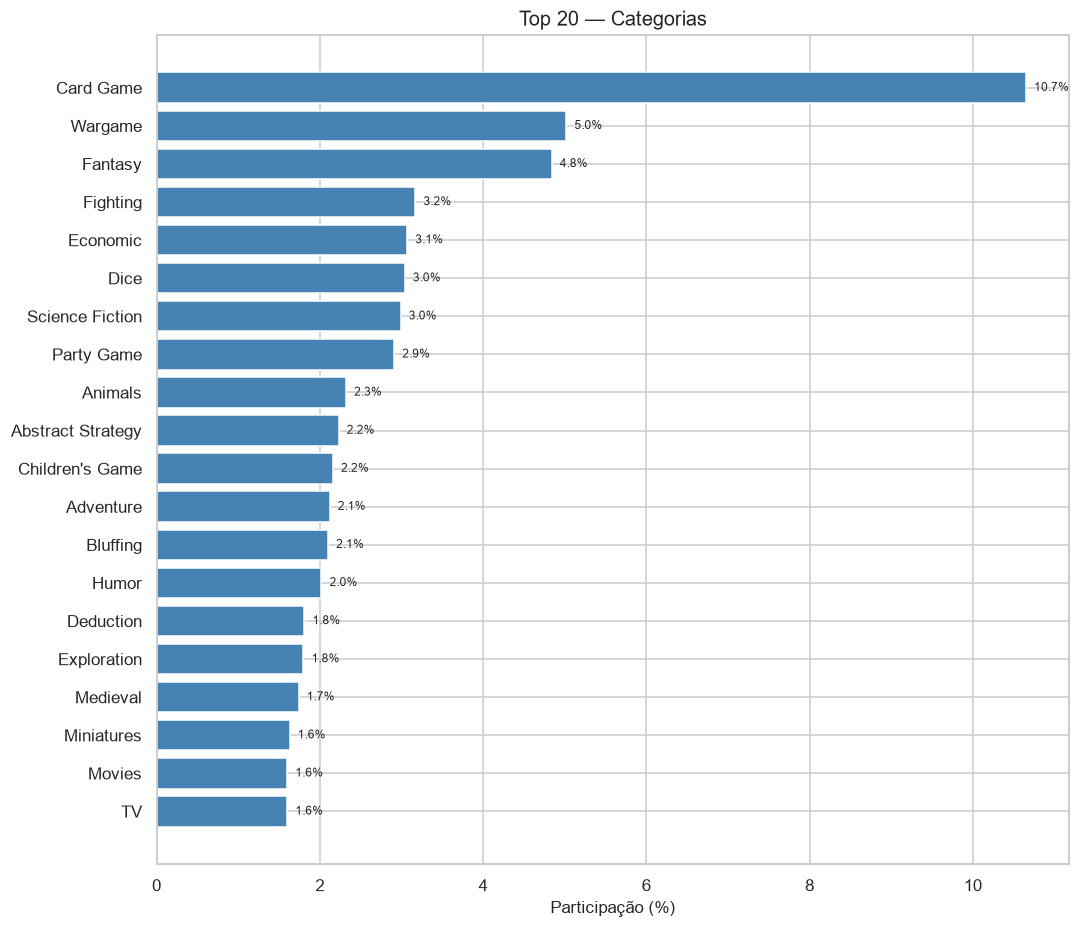

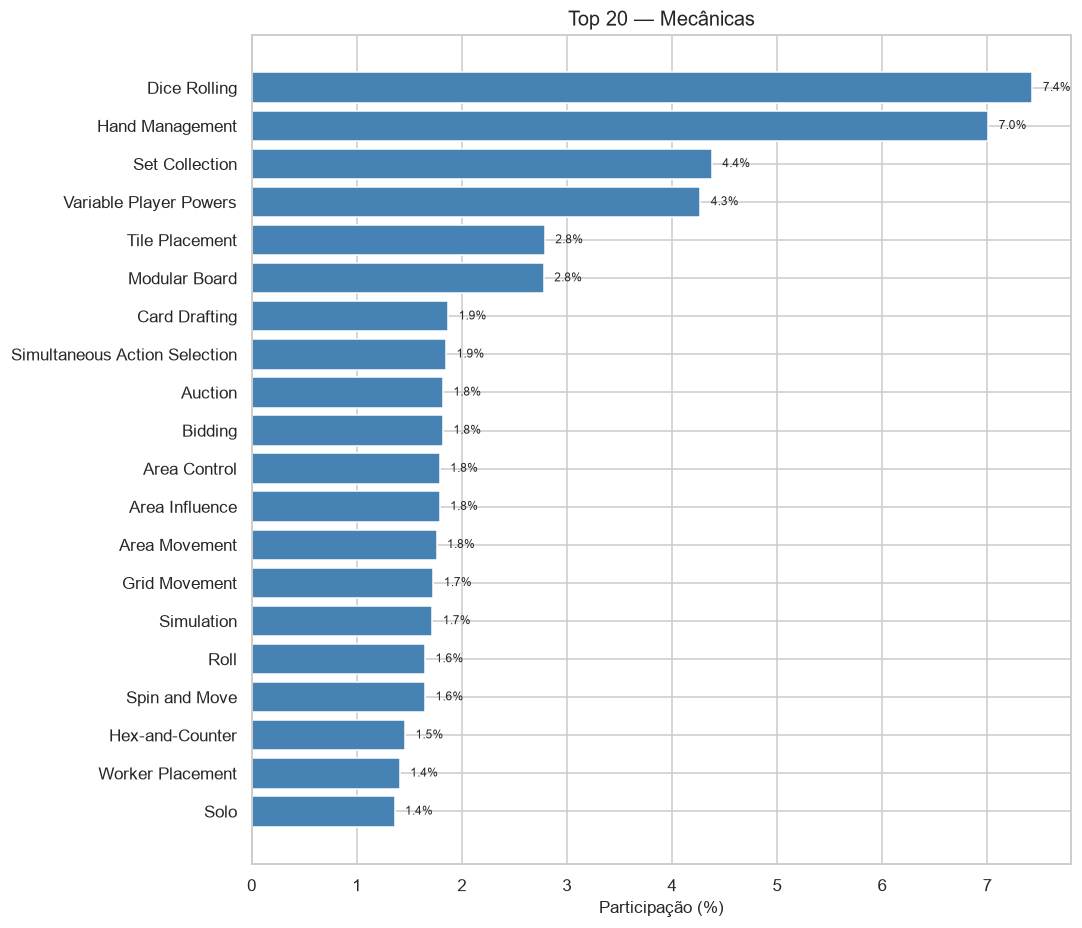

In [17]:
def plot_top_distribution(resumo: pd.DataFrame, col_name: str, top_n: int = 20):
    """Gráfico de barras horizontal para os top-N itens de uma coluna de listas."""
    top = resumo.head(top_n)

    fig, ax = plt.subplots(figsize=(10, top_n * 0.38 + 1))
    bars = ax.barh(top.index[::-1], top['Porcentagem (%)'][::-1],
                   color='steelblue', edgecolor='white')

    for bar, val in zip(bars, top['Porcentagem (%)'][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)

    ax.set_xlabel('Participação (%)')
    ax.set_title(f'Top {top_n} — {col_name}')
    plt.tight_layout()
    plt.show()

plot_top_distribution(resumo_cat, 'Categorias', top_n=20)
plot_top_distribution(resumo_mec, 'Mecânicas', top_n=20)

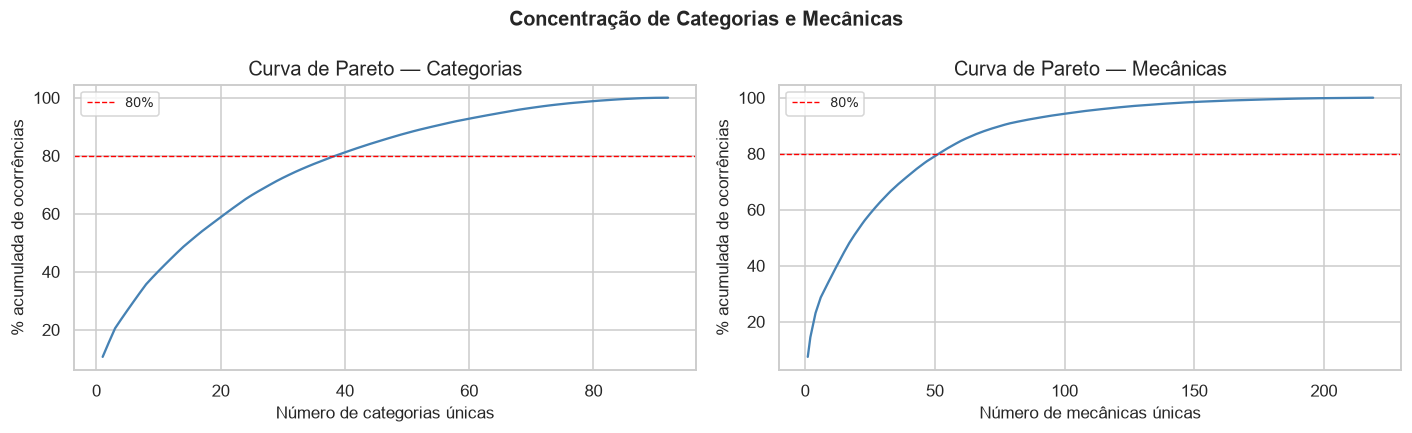

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, resumo, titulo in zip(
    axes,
    [resumo_cat, resumo_mec],
    ['Categorias', 'Mecânicas']
):
    n_items = range(1, len(resumo) + 1)
    ax.plot(n_items, resumo['Acumulada (%)'].values, color='steelblue')
    ax.axhline(80, color='red', linestyle='--', linewidth=0.9, label='80%')
    ax.set_xlabel(f'Número de {titulo.lower()} únicas')
    ax.set_ylabel('% acumulada de ocorrências')
    ax.set_title(f'Curva de Pareto — {titulo}')
    ax.legend(fontsize=9)

plt.suptitle('Concentração de Categorias e Mecânicas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

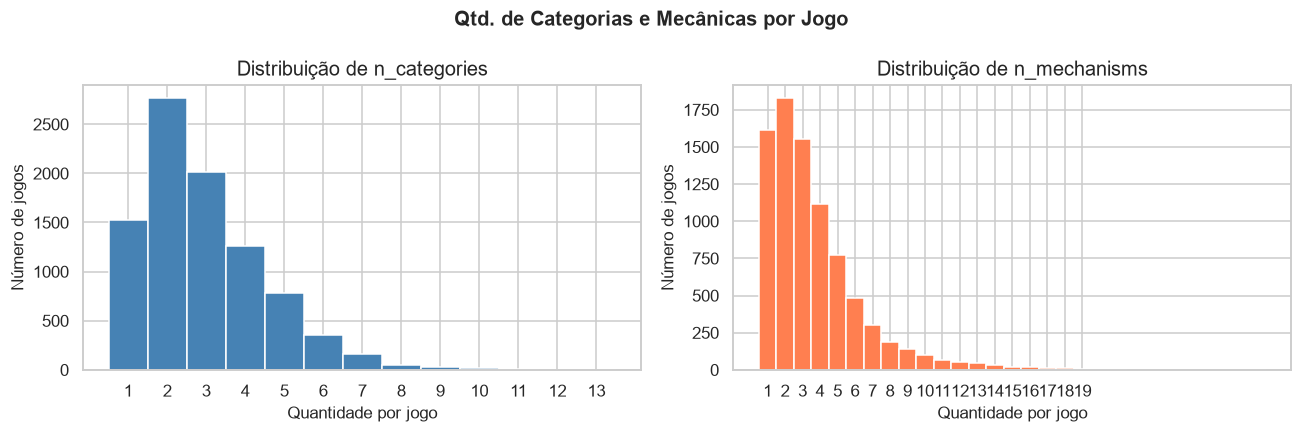

Categorias por jogo (mediana): 3.0
Mecânicas por jogo (mediana): 3.0


In [19]:
# Número de categorias e mecânicas por jogo
df['n_categories'] = df['categories'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
df['n_mechanisms'] = df['mechanisms'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, cor in zip(axes,
                        ['n_categories', 'n_mechanisms'],
                        ['steelblue', 'coral']):
    vals = df[df[col] > 0][col]
    ax.hist(vals, bins=range(1, vals.max() + 2), color=cor,
            edgecolor='white', align='left')
    ax.set_xlabel('Quantidade por jogo')
    ax.set_ylabel('Número de jogos')
    ax.set_title(f'Distribuição de {col}')
    ax.set_xticks(range(1, min(vals.max() + 1, 20)))

plt.suptitle('Qtd. de Categorias e Mecânicas por Jogo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Categorias por jogo (mediana):', df[df['n_categories'] > 0]['n_categories'].median())
print('Mecânicas por jogo (mediana):', df[df['n_mechanisms'] > 0]['n_mechanisms'].median())

## 7. Análise de Texto (Descrição) — TF-IDF + SVD

> Pipeline de redução de dimensionalidade para a coluna `description`, vindo do script de tratamento.

In [20]:
# Referência ao DataFrame tratado como ohe_df
ohe_df = df.copy()

mask_real = ohe_df['description'].notna()
textos_reais = ohe_df.loc[mask_real, 'description']

print(f'Total de linhas: {len(ohe_df)}')
print(f'Linhas com descrição real: {mask_real.sum()}')
print(f"Linhas sem descrição: {(~mask_real).sum()}")

Total de linhas: 24785
Linhas com descrição real: 18476
Linhas sem descrição: 6309


=== COMPRIMENTO DAS DESCRIÇÕES (palavras) ===
count    18476.0
mean        38.0
std         78.9
min          1.0
25%         10.0
50%         13.0
75%         15.0
max       1903.0
Name: description, dtype: float64


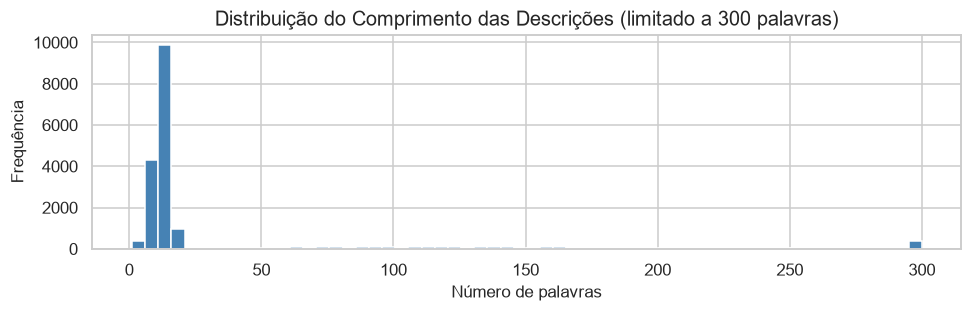

In [21]:
# Estatísticas descritivas das descrições
desc_len = textos_reais.str.split().str.len()

print('=== COMPRIMENTO DAS DESCRIÇÕES (palavras) ===')
print(desc_len.describe().round(1))

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(desc_len.clip(0, 300), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de palavras')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do Comprimento das Descrições (limitado a 300 palavras)')
plt.tight_layout()
plt.show()

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(textos_reais)

svd_test = TruncatedSVD(n_components=150, random_state=42)
svd_test.fit(tfidf_matrix)

variancia_individual = svd_test.explained_variance_ratio_
variancia_acumulada  = np.cumsum(variancia_individual)

print(f"\nVariância acumulada com 150 componentes: {variancia_acumulada[-1]*100:.2f}%")
print("(Mostrando que mesmo 150 componentes não chegam perto de 80%)\n")

LIMIAR_GANHO_RELATIVO = 0.20
ganho_relativo = variancia_individual / variancia_individual[0]

condicao_cotovelo = ganho_relativo <= LIMIAR_GANHO_RELATIVO
if np.any(condicao_cotovelo):
    n_ideal = np.argmax(condicao_cotovelo) + 1
else:
    n_ideal = len(variancia_individual)

TETO_COMPONENTES = 100
n_final = min(n_ideal, TETO_COMPONENTES)

print(f"Componente onde o ganho marginal cai abaixo de {LIMIAR_GANHO_RELATIVO*100:.0f}% do 1º: {n_ideal}")
print(f"Variância acumulada nesse ponto: {variancia_acumulada[n_final-1]*100:.2f}%")
print(f"Componentes finais (com teto de segurança): {n_final}")


Variância acumulada com 150 componentes: 42.79%
(Mostrando que mesmo 150 componentes não chegam perto de 80%)

Componente onde o ganho marginal cai abaixo de 20% do 1º: 68
Variância acumulada nesse ponto: 27.36%
Componentes finais (com teto de segurança): 68


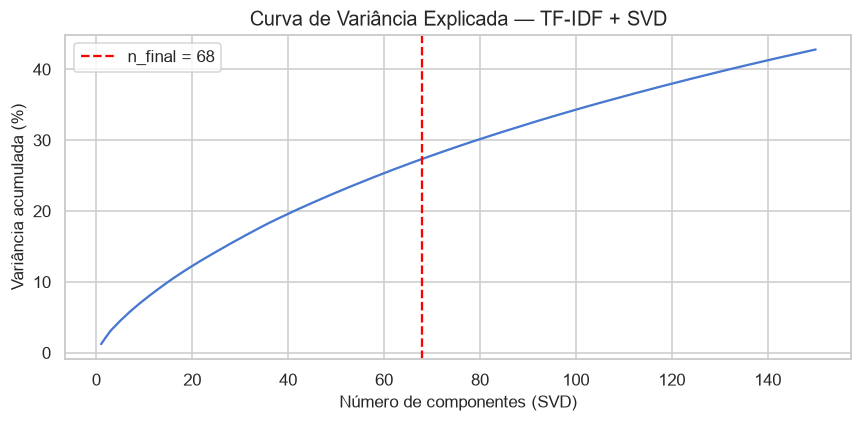

In [23]:
# Gráfico para visualizar o cotovelo
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada * 100)
plt.axvline(n_final, color='red', linestyle='--', label=f'n_final = {n_final}')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('Variância acumulada (%)')
plt.title('Curva de Variância Explicada — TF-IDF + SVD')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
feature_names = tfidf.get_feature_names_out()
n_show = 5
print(f'=== TOP {n_show} TERMOS DOS PRIMEIROS 5 COMPONENTES SVD ===')
for i in range(min(5, n_final)):
    component = svd_test.components_[i]
    top_terms = [feature_names[j] for j in component.argsort()[:-n_show-1:-1]]
    print(f'  Componente {i+1}: {top_terms}')

=== TOP 5 TERMOS DOS PRIMEIROS 5 COMPONENTES SVD ===
  Componente 1: ['game', 'cards', 'card', 'players', 'player']
  Componente 2: ['build', 'cards', 'best', 'players', 'race']
  Componente 3: ['build', 'game', 'best', 'world', 'city']
  Componente 4: ['war', 'world', 'battle', 'fight', 'wargame']
  Componente 5: ['dice', 'race', 'roll', 'best', 'collect']


## 8. Análise Bivariada

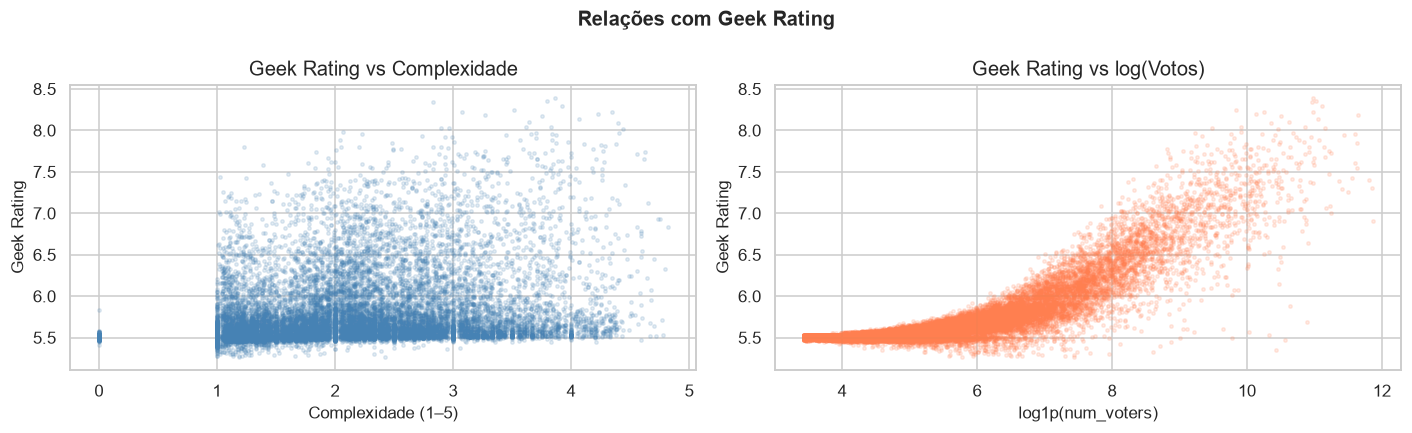

In [25]:
# Geek Rating vs Complexity
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['complexity'], df['geek_rating'],
                alpha=0.15, s=5, color='steelblue')
axes[0].set_xlabel('Complexidade (1–5)')
axes[0].set_ylabel('Geek Rating')
axes[0].set_title('Geek Rating vs Complexidade')

axes[1].scatter(np.log1p(df['num_voters']), df['geek_rating'],
                alpha=0.15, s=5, color='coral')
axes[1].set_xlabel('log1p(num_voters)')
axes[1].set_ylabel('Geek Rating')
axes[1].set_title('Geek Rating vs log(Votos)')

plt.suptitle('Relações com Geek Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

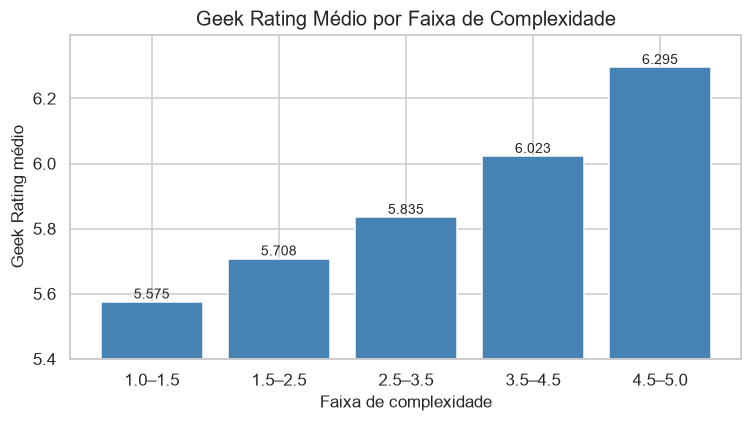

In [ ]:
df['complexity_bin'] = pd.cut(
    df['complexity'],
    bins=[0, 1.5, 2.5, 3.5, 4.5, 5.01],
    labels=['1.0–1.5', '1.5–2.5', '2.5–3.5', '3.5–4.5', '4.5–5.0']
)

grp = df.groupby('complexity_bin', observed=True)['geek_rating'].mean().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(grp.index, grp.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Faixa de complexidade')
ax.set_ylabel('Geek Rating médio')
ax.set_title('Geek Rating Médio por Faixa de Complexidade')
ax.set_ylim(5.4, grp.max() + 0.1)
for i, v in enumerate(grp.values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

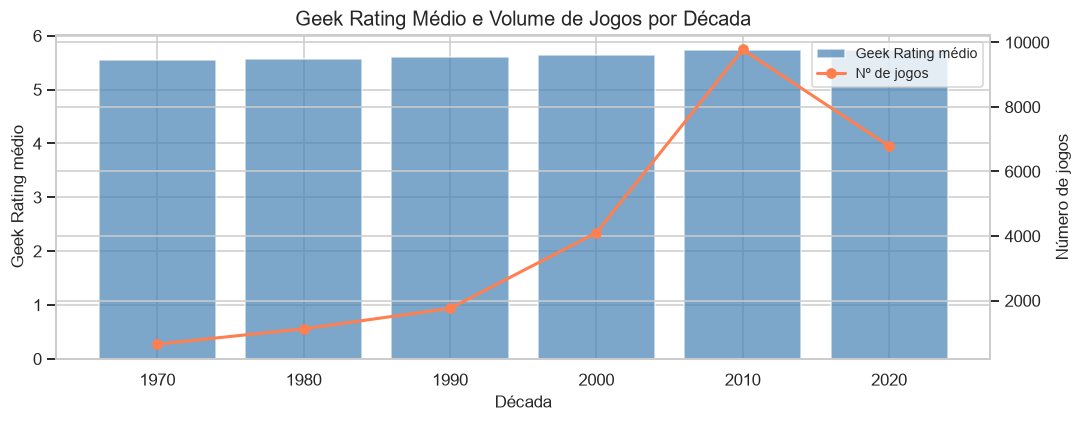

In [ ]:
df['decade'] = (df['year'] // 10 * 10).astype('Int64')
decade_grp = (
    df[df['decade'] >= 1970]
    .groupby('decade', observed=True)['geek_rating']
    .agg(['mean', 'count'])
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(decade_grp['decade'].astype(str), decade_grp['mean'],
        color='steelblue', alpha=0.7, label='Geek Rating médio')
ax2.plot(decade_grp['decade'].astype(str), decade_grp['count'],
         color='coral', marker='o', linewidth=2, label='Nº de jogos')

ax1.set_xlabel('Década')
ax1.set_ylabel('Geek Rating médio')
ax2.set_ylabel('Número de jogos')
ax1.set_title('Geek Rating Médio e Volume de Jogos por Década')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
plt.tight_layout()
plt.show()

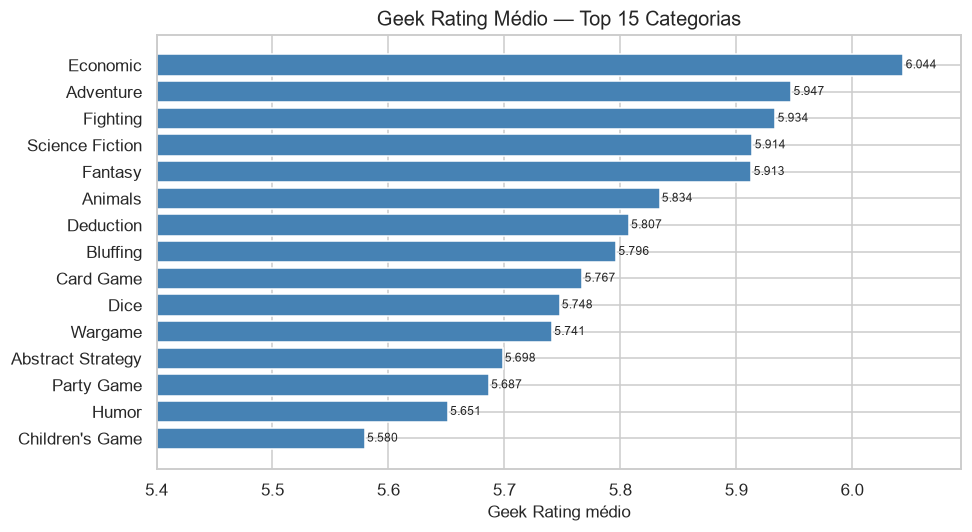

In [ ]:
top_cats = resumo_cat.head(15).index.tolist()

rows = []
for _, row in df.iterrows():
    if isinstance(row['categories'], list):
        for cat in row['categories']:
            if cat in top_cats:
                rows.append({'category': cat, 'geek_rating': row['geek_rating']})

df_cat_rating = pd.DataFrame(rows)
cat_mean = (
    df_cat_rating.groupby('category')['geek_rating']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cat_mean.index, cat_mean.values, color='steelblue')
ax.set_xlabel('Geek Rating médio')
ax.set_title('Geek Rating Médio — Top 15 Categorias')
ax.set_xlim(5.4, cat_mean.max() + 0.05)
for i, v in enumerate(cat_mean.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Correlações

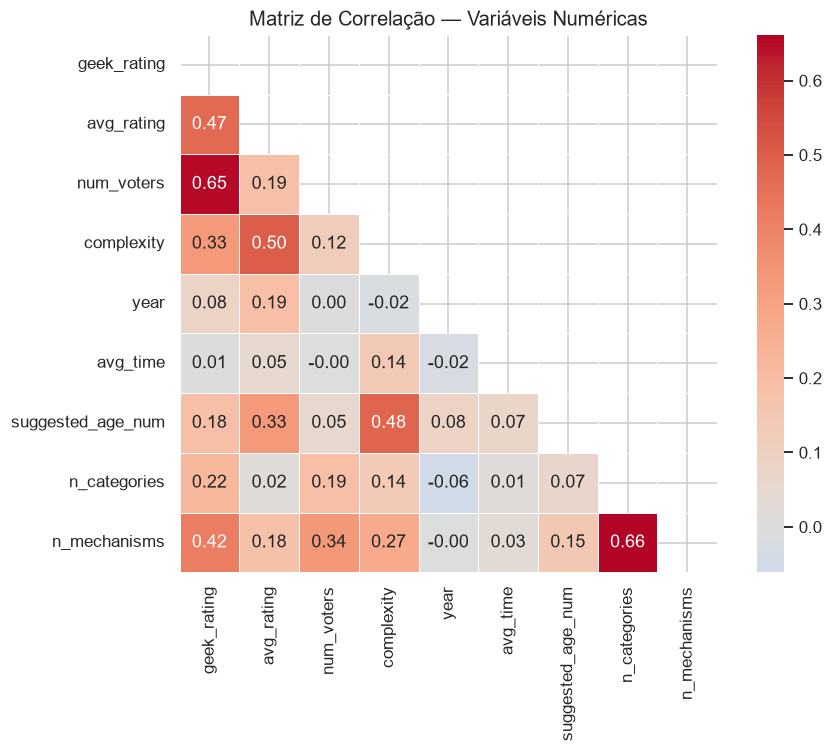

In [29]:
corr_cols = ['geek_rating', 'avg_rating', 'num_voters', 'complexity',
             'year', 'avg_time', 'suggested_age_num',
             'n_categories', 'n_mechanisms']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

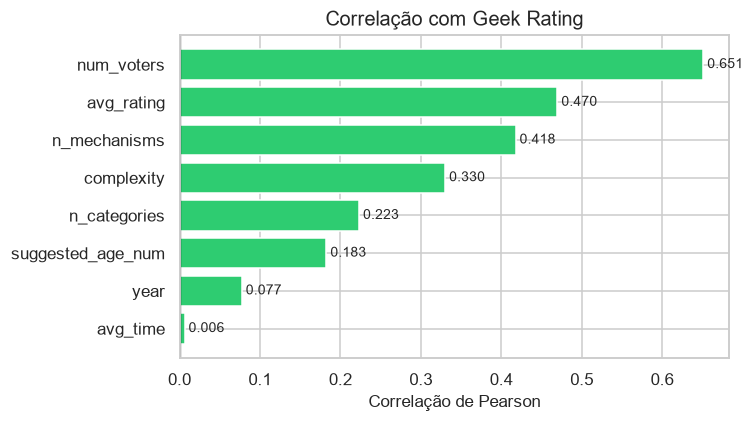

In [30]:
# Correlação com geek_rating (ordenada)
corr_target = corr_matrix['geek_rating'].drop('geek_rating').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação de Pearson')
ax.set_title('Correlação com Geek Rating')
for i, v in enumerate(corr_target.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Conclusões da EDA

### Dataset
- **24.785 jogos** ranqueados no BGG, com 19 colunas originais.
- Colunas `developer` e `price` têm ~97% de ausência e dificilmente serão úteis diretamente na modelagem.
- Colunas de lista (`categories`, `mechanisms`, `designers`, etc.) precisam de explosão (explode/OHE) antes do uso.

### Variáveis numéricas
- **`geek_rating`** tem distribuição concentrada entre 5.2 e 5.8 (efeito do sistema Bayesiano do BGG); **`avg_rating`** tem maior dispersão.
- **`num_voters`** é extremamente assimétrico (cauda longa) → transformação `log1p` recomendada.
- **`complexity`** tem correlação positiva com `geek_rating`, indicando que jogos mais complexos tendem a ser melhor avaliados no BGG.
- O número de lançamentos cresce fortemente a partir dos anos 2000, com pico na última década.

### Categorias e Mecânicas
- As **top ~40 categorias** (42% do total) cobrem ~81.6% das ocorrências — forte concentração de Pareto.
- As **top ~55 mecânicas** (25% do total) cobrem ~82.5% das ocorrências.
- Mediana de **3 categorias** e **6 mecânicas** por jogo.

### Texto (Descrição) — TF-IDF + SVD
- 150 componentes SVD não atingem 80% de variância explicada, confirmando alta dispersão semântica.
- O critério de cotovelo (queda de ganho marginal a 20% do 1º componente) determina `n_final` seguro para o pipeline.

### Correlações com `geek_rating`
- Maior correlação positiva: `complexity` e `num_voters` (log).
- Correlação ligeiramente negativa com `avg_time` — jogos muito longos não necessariamente são melhor ranqueados.
- `n_mechanisms` tem correlação positiva, sugerindo que maior diversidade mecânica favorece notas mais altas.